Select the features with obvious importance

no tamb, tamb_lag_1, CH4_rt_diff_1, pamb_lag_1, pamb, is_bad_std, psamp_lag_1, psamp, is_protential_flagged_air, tmod, tmod_lag_1

In [7]:
# data tools and plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay


In [8]:
class TSFE(BaseEstimator, TransformerMixin):
    def __init__(self, feature_cols,  feature_config, target_col='label1'):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.feature_config = feature_config
    #==========
    def fit (self, X, y=None):
        return self
    #=============
    def _fill_Nan(self, df, feature_col):
        for i in feature_col:
            df[i] = df[i].ffill().fillna(0)
        return df
    # ============
    def _ratio_featutre_gen(self, df):
        df['CH4_area_ht_ratio'] = df['CH4_area']/df['CH4_ht']
        df['CH4_w_ht_ratio'] = df['CH4_w']/df['CH4_ht']
        df['psamp_pflow_ratio'] = df['psamp']/df['pflow']
        df['w_duration_ratio'] = df['CH4_w']/df['duration']

        fill_feature_ratio = ['CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio','w_duration_ratio']
        for i in fill_feature_ratio :
            df[i] = df[i].fillna(0)
        return df

    #=============== diff, lag, rolling
    def _diff_gen(self, df, feature, period):
        df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

        return df
    #===============
    def _lag_gen (self, df, feature, period):
        df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
        return df

    #===============
    def _rolling_std_gen (self, df, feature, period):
        df[f'{feature}_roll_std_{period}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').std()).fillna(0)# self not included, NAN->0
        return df

    #===============
    def _rolling_mean_residual_gen(self, df, feature, period):
        df[f'{feature}_roll_mean_{period}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').mean().fillna(0) # self not included
        df[f'{feature}_residual_{period}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{period}']# self not included
        return df
    #================
    def _feature_eng_apply(self, df, config):
        for opt, params in config.items():
            cols = params['cols']
            period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

            for feature in cols:
                if opt == 'diff':
                    df = self._diff_gen(df, feature, period)
                elif opt == 'lag':
                    df = self._lag_gen(df, feature, period)
                elif opt == 'roll_std':
                    df = self._rolling_std_gen( df, feature, period)
                elif opt == 'roll_mean_res':
                    df = self._rolling_mean_residual_gen(df, feature, period)
        return df 

    def transform(self, X):
        df = X.copy()
        #df = self._fill_Nan(df, self.feature_cols)
        df = df.set_index('datetime')
        df = self._fill_Nan(df, self.feature_cols)
        df = self._ratio_featutre_gen(df)
        df.index = pd.to_datetime(df.index)
        df = self._feature_eng_apply(df, self.feature_config)
        df = self._fill_Nan(df, self.feature_cols)

        return df

no :tamb,  pamb,  tmod, (psamp) save todo psamp/pflow ratio feature
tamb_lag_1, pamb_lag_1 , psamp_lag_1, tmod_lag_1
CH4_rt_diff_1,
is_bad_std,
is_protential_flagged_air,

In [9]:

feature_cols= [#'datetime', 
  #'tamb', , 'pamb' ,'tmod', 
  'psamp','pflow',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 
       'is_ht_zero_and_C_Nan','is_normal_std', #'is_bad_std', 'is_protential_flagged_air'
       ]



feature_config ={
    'diff':{'cols': ['CH4_area', 'CH4_ht', #'CH4_rt'
                    ], 'periods':1},
    'lag':{'cols':['CH4_area', 'CH4_rt', #'tmod',  'psamp','pamb','tamb',
                   'pflow','CH4_w','CH4_skew'], 'periods':1},

    'roll_std':{'cols': ['CH4_w', 'CH4_skew'], 'period':'14D'},
    'roll_mean_res':{'cols':['CH4_rt', 'CH4_start_time', 'CH4_w', 'CH4_skew'], 'period': '14D'}
}

In [10]:
sns.set_theme(style='darkgrid')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/processed/mhd_ch4_simple_v2.csv')
#print(df.head())


df = df.drop(df[df['year']==2026].index)# the latest years'data wouldn't be used
#print(df['year'].unique()) 

year_dummies = pd.get_dummies(df['year'], prefix='is_year_').astype(int) # set every year as a features
df= pd.concat([df, year_dummies], axis=1)
df = df.set_index('datetime')
df = df.reset_index()
#=========
X = df[['datetime']+feature_cols]
y = df['label1']
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]



tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)


Index(['datetime', 'psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'duration', 'is_ht_zero_and_C_Nan', 'is_normal_std'],
      dtype='object')


In [13]:
import shap

pipe_rnd = Pipeline([
    ('tsfe', TSFE(feature_cols=feature_cols, feature_config=feature_config)),
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': list(range(5, 15, 5)),
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[1,2,4],
    'clf__max_features':['sqrt']
}

#'clf__min_samples_leaf': best 2

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[1,2,3],
    'clf__max_features':['sqrt']
}

In [21]:
random_search= RandomizedSearchCV(
    estimator=pipe_rnd,
    param_distributions=param_grid,
    n_iter=4,
    cv = tscv,
    scoring='average_precision',
    random_state=42
)

random_search.fit(X_train, y_train)

ValueError: 
All the 20 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/pipeline.py", line 649, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py", line 334, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        ensure_all_finite=False,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py", line 3055, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py", line 1327, in check_X_y
    X = check_array(
        X,
    ...<12 lines>...
        input_name="X",
    )
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py", line 1035, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/_array_api.py", line 976, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "/home/ellie/research_project/.venv/lib/python3.13/site-packages/pandas/core/generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: '1994-02-16 14:29:00'


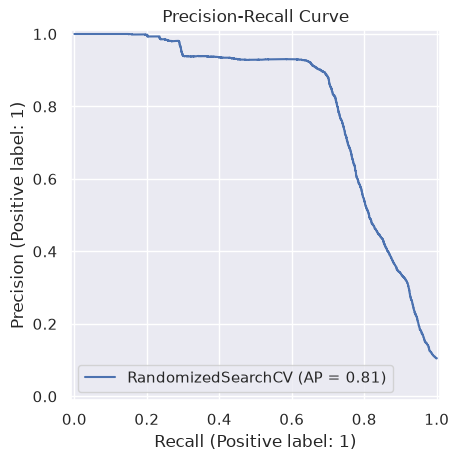

In [8]:

PrecisionRecallDisplay.from_estimator(random_search, X_test, y_test)

plt.title('Precision-Recall Curve')
plt.show()

In [9]:
joblib.dump(random_search.best_estimator_, 'model/0706_rf_best_randomsearch_v1.pkl')

['model/0706_rf_best_randomsearch_v1.pkl']

-------------------


In [19]:
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)

X_train_final.head()

,psamp,pflow,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration,is_ht_zero_and_C_Nan,is_normal_std,CH4_area_ht_ratio,CH4_w_ht_ratio,psamp_pflow_ratio,w_duration_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_area_lag_1,CH4_rt_lag_1,pflow_lag_1,CH4_w_lag_1,CH4_skew_lag_1,CH4_w_roll_std_14D,CH4_skew_roll_std_14D,CH4_rt_roll_mean_14D,CH4_rt_residual_14D,CH4_start_time_roll_mean_14D,CH4_start_time_residual_14D,CH4_w_roll_mean_14D,CH4_w_residual_14D,CH4_skew_roll_mean_14D,CH4_skew_residual_14D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,761.10,841.9,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1,0,0.000000,0.000000,0.904027,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.000000,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0000,0.0000
1994-02-16 14:49:00,761.07,840.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1,0,0.000000,0.000000,0.905604,0.000000,0.0,0.0,0.0,0.0,841.9,0.00,0.00,0.000000,0.000000,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0000,0.0000
1994-02-16 15:09:00,760.99,839.4,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,33.4,0,0,2.600415,0.000014,0.906588,0.077844,496440.0,190908.0,0.0,0.0,840.4,0.00,0.00,0.000000,0.000000,0.00,109.80,0.00,102.00,0.000000,2.600000,0.0000,0.6300
1994-02-16 15:29:00,760.96,839.6,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,42.8,0,0,7.028437,0.000045,0.906336,0.160047,569542.0,-39241.0,496440.0,109.8,839.4,2.60,0.63,1.501111,0.363731,36.60,58.20,34.00,52.20,0.866667,5.983333,0.2100,0.8100
1994-02-16 18:00:00,760.72,845.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1,0,0.000000,0.000000,0.899834,0.000000,-1065982.0,-151667.0,1065982.0,94.8,839.6,6.85,1.02,3.233000,0.502220,51.15,-51.15,47.05,-47.05,2.362500,-2.362500,0.4125,-0.4125


In [16]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()

pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [4,5,6,7],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[2],
    'clf__max_features':['sqrt']
}

In [ ]:
grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
grid.fit(X_train_final, y_train_final)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__class_weight': ['balanced'], 'clf__max_depth': [4, 5, ...], 'clf__max_features': ['sqrt'], 'clf__min_samples_leaf': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchang

In [ ]:
cv_results = pd.DataFrame(grid.cv_results_)
best_index = grid.best_index_
mean_train = cv_results.loc[best_index, 'mean_train_score']
mean_test = cv_results.loc[best_index, 'mean_test_score']

print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

In [22]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['psamp','pflow','CH4_rt',...,'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D','CH4_skew_residual_14D']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [23]:
joblib.dump(grid.best_estimator_, 'model/0706_rf_best_grid_v2.pkl')

['model/0706_rf_best_grid_v2.pkl']

In [24]:
joblib.dump(grid, 'model/0706_rf_grid_v2.pkl')
print('Done!')

Done!


grid = joblib.load('model/0706_rf_grid_v1.pkl')

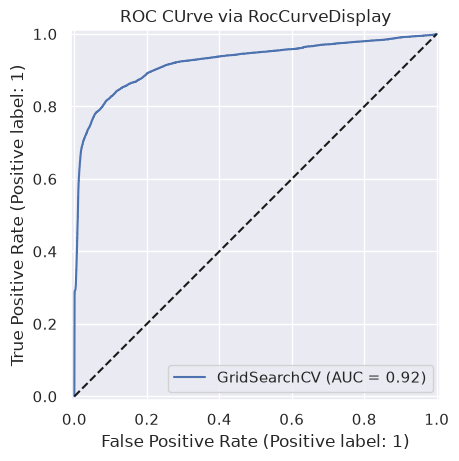

In [26]:
X_test_final = tsfe.fit_transform(X_test)
y_test_final = y_test.copy()
RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--') 
plt.show()


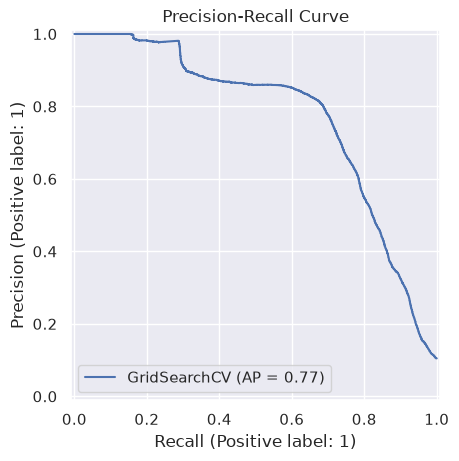

In [27]:

PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title('Precision-Recall Curve')
plt.show()

In [29]:
X_test_final.columns

Index(['psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'duration', 'is_ht_zero_and_C_Nan', 'is_normal_std',
       'CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio',
       'w_duration_ratio', 'CH4_area_diff_1', 'CH4_ht_diff_1',
       'CH4_area_lag_1', 'CH4_rt_lag_1', 'pflow_lag_1', 'CH4_w_lag_1',
       'CH4_skew_lag_1', 'CH4_w_roll_std_14D', 'CH4_skew_roll_std_14D',
       'CH4_rt_roll_mean_14D', 'CH4_rt_residual_14D',
       'CH4_start_time_roll_mean_14D', 'CH4_start_time_residual_14D',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D',
       'CH4_skew_residual_14D'],
      dtype='object')

In [ ]:
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']

X_tsfe_demo = best_pipeline.named_steps['tsfe'].transform(X_test.head(2))
X_tsfe_demo.head()

,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration,is_ht_zero_and_C_Nan,is_bad_std,is_normal_std,is_protential_flagged_air,CH4_area_ht_ratio,CH4_w_ht_ratio,psamp_pflow_ratio,w_duration_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_rt_diff_1,CH4_area_lag_1,CH4_rt_lag_1,tmod_lag_1,tamb_lag_1,pflow_lag_1,psamp_lag_1,pamb_lag_1,CH4_w_lag_1,CH4_skew_lag_1,CH4_w_roll_std_14D,CH4_skew_roll_std_14D,CH4_rt_roll_mean_14D,CH4_rt_residual_14D,CH4_start_time_roll_mean_14D,CH4_start_time_residual_14D,CH4_w_roll_mean_14D,CH4_w_residual_14D,CH4_skew_roll_mean_14D,CH4_skew_residual_14D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-07-21 18:43:00,40.0,19.77,803.7,752.75,752.7,102.2,7.37,142932.0,1230362.0,0.9,88.2,140.8,29213.0,29627.0,52.6,0,0,1,0,8.608023,0.000052,0.936606,0.140114,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,102.2,0.0,88.2,0.00,7.37,0.0,0.9
2019-07-21 19:03:00,40.0,19.73,806.8,752.89,752.8,102.2,7.39,139718.0,1206045.0,0.9,88.2,140.6,29194.0,29662.0,52.4,0,0,0,0,8.631994,0.000053,0.933180,0.141031,-24317.0,-3214.0,0.0,1230362.0,102.2,40.0,19.77,803.7,752.75,752.7,7.37,0.9,0.0,0.0,102.2,0.0,88.2,0.0,7.37,0.02,0.9,0.0


In [ ]:
import shap
#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


#X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)


feature_names = X_test_final.columns

X_test_transformed_df = pd.DataFrame(X_test_final, columns =feature_names)
X_test_transformed_df.isna().sum()

tmod                            0
tamb                            0
pflow                           0
psamp                           0
pamb                            0
CH4_rt                          0
CH4_w                           0
CH4_ht                          0
CH4_area                        0
CH4_skew                        0
CH4_start_time                  0
CH4_end_time                    0
CH4_start_level                 0
CH4_end_level                   0
duration                        0
is_ht_zero_and_C_Nan            0
is_bad_std                      0
is_normal_std                   0
is_protential_flagged_air       0
CH4_area_ht_ratio               0
CH4_w_ht_ratio                  0
psamp_pflow_ratio               0
w_duration_ratio                0
CH4_area_diff_1                 0
CH4_ht_diff_1                   0
CH4_rt_diff_1                   0
CH4_area_lag_1                  0
CH4_rt_lag_1                    0
tmod_lag_1                      0
tamb_lag_1    

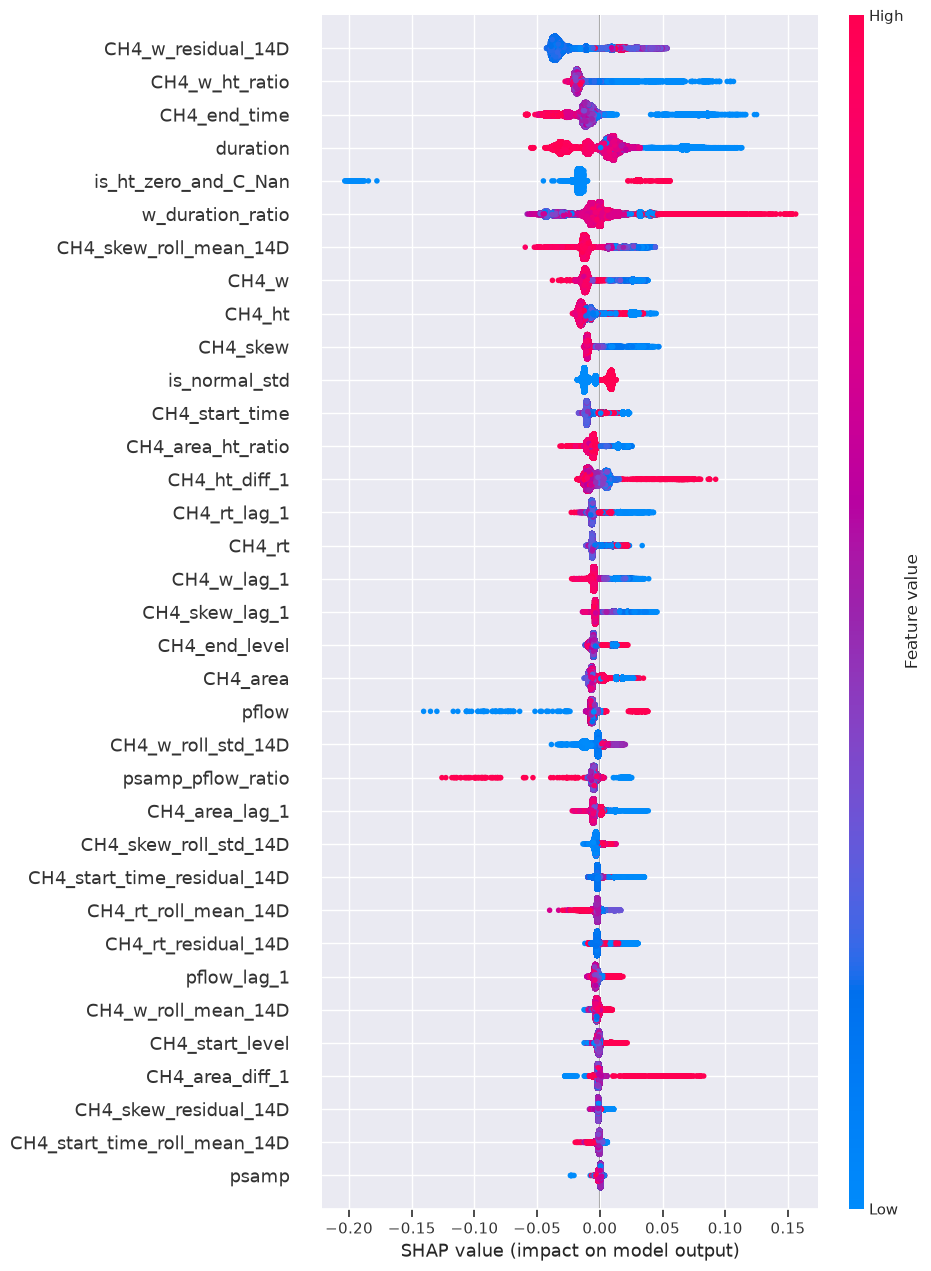

In [30]:
import shap
#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


#X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)

explainer = shap.TreeExplainer(final_rf_model)
shap_values = explainer(X_test_final)

shap.plots.beeswarm(shap_values[:, :, 1], max_display=46) # label1 = 1

------

In [ ]:
# Learning curve
from sklearn.model_selection import LearningCurveDisplay
best_param = grid.best_estimator_

eval_pipeline = pipe_rnd.set_params(**best_param)

LearningCurveDisplay.from_estimator(
    eval_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    n_jobs=-1
)

plt.title("Learning Curve (Random Forest)")
plt.show()